In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [23]:
data = pd.read_csv("pesticides.csv")
data.head()

,Domain,Area,Element,Item,Year,Unit,Value
0,Pesticides Use,Albania,Use,Pesticides (total),1990,tonnes of active ingredients,121.0
1,Pesticides Use,Albania,Use,Pesticides (total),1991,tonnes of active ingredients,121.0
2,Pesticides Use,Albania,Use,Pesticides (total),1992,tonnes of active ingredients,121.0
3,Pesticides Use,Albania,Use,Pesticides (total),1993,tonnes of active ingredients,121.0
4,Pesticides Use,Albania,Use,Pesticides (total),1994,tonnes of active ingredients,201.0


In [24]:
data.columns = data.columns.str.strip()

In [25]:
print(data.columns)
print(data["Area"].unique())

Index(['Domain', 'Area', 'Element', 'Item', 'Year', 'Unit', 'Value'], dtype='object')
['Albania' 'Algeria' 'Angola' 'Antigua and Barbuda' 'Argentina' 'Armenia'
 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh'
 'Barbados' 'Belarus' 'Belgium' 'Belgium-Luxembourg' 'Belize' 'Bermuda'
 'Bhutan' 'Bolivia (Plurinational State of)' 'Botswana' 'Brazil'
 'Brunei Darussalam' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cabo Verde'
 'Cameroon' 'Canada' 'Central African Republic' 'Chad' 'Chile'
 'China, Hong Kong SAR' 'China, Macao SAR' 'China, mainland'
 'China, Taiwan Province of' 'Colombia' 'Comoros' 'Congo' 'Cook Islands'
 'Costa Rica' "Côte d'Ivoire" 'Croatia' 'Cyprus' 'Czechia' 'Denmark'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Eritrea' 'Estonia'
 'Ethiopia' 'Fiji' 'Finland' 'France' 'French Polynesia' 'Gambia'
 'Germany' 'Ghana' 'Greece' 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana'
 'Haiti' 'Honduras' 'Hungary' 'Iceland' 'India' 'Indonesia'
 'Iran (Islamic Republic

In [26]:
country = input("Enter Country Name : ")
df = data[data["Area"] == country]
df

Enter Country Name :  India


,Domain,Area,Element,Item,Year,Unit,Value
1817,Pesticides Use,India,Use,Pesticides (total),1990,tonnes of active ingredients,75000.00
1818,Pesticides Use,India,Use,Pesticides (total),1991,tonnes of active ingredients,72133.00
1819,Pesticides Use,India,Use,Pesticides (total),1992,tonnes of active ingredients,70791.00
1820,Pesticides Use,India,Use,Pesticides (total),1993,tonnes of active ingredients,66388.00
1821,Pesticides Use,India,Use,Pesticides (total),1994,tonnes of active ingredients,61357.00
1822,Pesticides Use,India,Use,Pesticides (total),1995,tonnes of active ingredients,61257.00
1823,Pesticides Use,India,Use,Pesticides (total),1996,tonnes of active ingredients,56114.00
1824,Pesticides Use,India,Use,Pesticides (total),1997,tonnes of active ingredients,52279.00
1825,Pesticides Use,India,Use,Pesticides (total),1998,tonnes of active ingredients,49157.00
1826,Pesticides Use,India,Use,Pesticides (total),1999,tonnes of active ingredients,46195.00


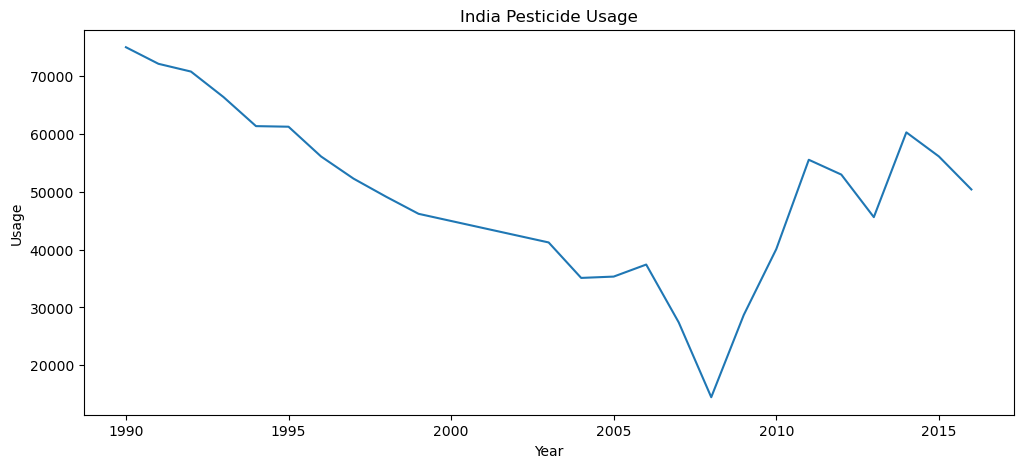

In [27]:
df = df.sort_values("Year")
plt.figure(figsize=(12,5))
plt.plot(df["Year"], df["Value"])
plt.title(country + " Pesticide Usage")
plt.xlabel("Year")
plt.ylabel("Usage")
plt.show()

In [28]:
values = df["Value"].values.reshape(-1,1)
values

array([[75000.  ],
       [72133.  ],
       [70791.  ],
       [66388.  ],
       [61357.  ],
       [61257.  ],
       [56114.  ],
       [52279.  ],
       [49157.  ],
       [46195.  ],
       [44957.52],
       [43720.04],
       [42482.56],
       [41245.08],
       [35113.  ],
       [35342.  ],
       [37423.  ],
       [27422.77],
       [14485.33],
       [28707.01],
       [40093.69],
       [55540.  ],
       [52980.  ],
       [45620.  ],
       [60280.  ],
       [56120.  ],
       [50410.  ]])

In [29]:
scaler = MinMaxScaler()
values = scaler.fit_transform(values)
values

array([[1.        ],
       [0.95262306],
       [0.93044662],
       [0.8576874 ],
       [0.77455053],
       [0.77289804],
       [0.68791039],
       [0.62453732],
       [0.57294653],
       [0.52399972],
       [0.50355046],
       [0.48310121],
       [0.46265195],
       [0.44220269],
       [0.34087057],
       [0.34465478],
       [0.37904313],
       [0.21379014],
       [0.        ],
       [0.23501211],
       [0.42317607],
       [0.67842508],
       [0.63612129],
       [0.51449789],
       [0.7567532 ],
       [0.68800954],
       [0.59365225]])

In [30]:
X = []
y = []
for i in range(3, len(values)):
    X.append(values[i-3:i,0])
    y.append(values[i,0])
X = np.array(X)
y = np.array(y)
X = X.reshape((X.shape[0], X.shape[1], 1))
print(X.shape)

(24, 3, 1)


In [37]:
model = Sequential()
model.add(SimpleRNN(50,activation="tanh",input_shape=(3,1)))
model.add(Dense(1))
model.compile(optimizer="adam",loss="mse")
model.summary()

C:\Users\tamil\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.fit(X,y,epochs=50,batch_size=4)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0206
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0154
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0154
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0154
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0161
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0154
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0133
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0154
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0139
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0135
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0135     
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0132 
Epoch 13/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0135
Epoch 14/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0136    
Epoch 15/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0138
Epoch 16/50
6/6 ━━━━━━━━━━

In [38]:
v1 = float(input("Enter Usage Year 1 : "))
v2 = float(input("Enter Usage Year 2 : "))
v3 = float(input("Enter Usage Year 3 : "))

Enter Usage Year 1 :  200
Enter Usage Year 2 :  250
Enter Usage Year 3 :  300


In [39]:
test = np.array([[v1],[v2],[v3]])
test = scaler.transform(test)
test = test.reshape((1,3,1))
pred = model.predict(test)
pred = scaler.inverse_transform(pred)
print("Predicted Next Year Usage :")
print(pred[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
Predicted Next Year Usage :
16573.021


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step


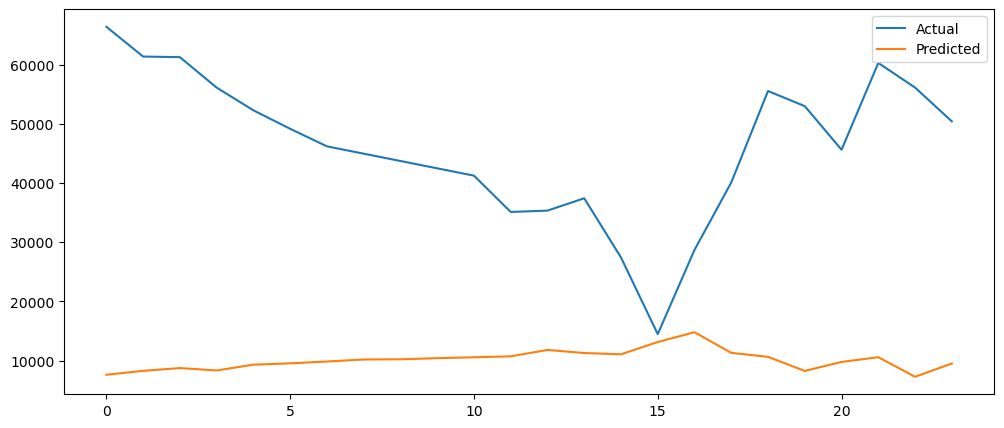

In [40]:
predictions = model.predict(X)
predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y.reshape(-1,1))
plt.figure(figsize=(12,5))
plt.plot(actual,label="Actual")
plt.plot(predictions,label="Predicted")
plt.legend()
plt.show()